In [4]:
""" Problem 8.3.5 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

In [8]:
wp = 1
Hp = 10**(-0.5/20)
ws = 5
Hs = 10**(-20/20)

eps = sqrt((1/Hp**2) - 1)
aa = np.arccosh((1/eps)*sqrt((1/Hs**2)-1))
bb = 1 / np.arccosh(ws)
n = aa * bb
print('n = ', n)

n =  1.7632762536991264


<>:40: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_8632\2479064672.py:40: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


alpha =  5.895180415135053
a =  1.0080687610207608  b =  1.4199305007449947


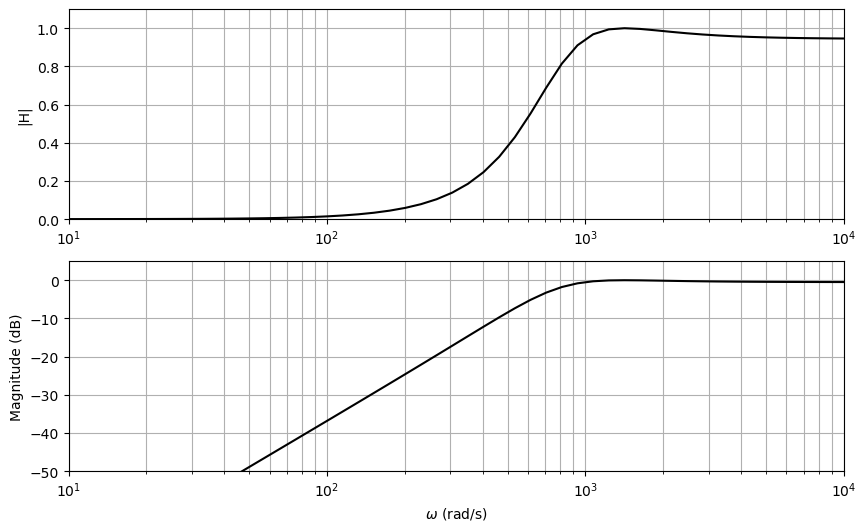

In [85]:
n = 2

alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ', alpha)

a = 0.5 * (alpha**(1/n) - alpha**(-1/n))
b = 0.5 * (alpha**(1/n) + alpha**(-1/n))
print('a = ', a, ' b = ', b)

theta = (180 - 45) * (pi/180) #90 for 2 poles
d1 = [1, -2*a*cos(theta), (a**2)*cos(theta)**2 + (b**2)*sin(theta)**2]

K = d1[2]*Hp

num = [0, 0, K]
den = d1

numh = num[::-1]
denh = den[::-1]

a = 1000
nums = [numh[0],a*numh[1],(a**2)*numh[2]]
dens = [denh[0],a*denh[1],(a**2)*denh[2]]

system = sig.TransferFunction(nums, dens)
w, Hmag, Hphase = sig.bode(system)

plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k')
plt.axis([1e1,1e4,0,1.1])
plt.grid(which='both')
plt.ylabel('|H|')

plt.subplot(212)
plt.semilogx(w, Hmag, 'k')
plt.axis([1e1,1e4,-50,5])
plt.ylabel('Magnitude (dB)')
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.show()